In [35]:
SANITY_K = 50          # top-K documents per axis
SANITY_AXES = ["инфляция", "дкп", "курс", "продовольствие"]  # axes to inspect manually
TOKENS_PER_CHAR = 1 / 3.5  # rough estimate for Russian text

In [36]:
def top_k_by_axis(df, query_vectors, k, exclude_channel=None):
    """Return dict[axis -> DataFrame] with top-k documents per axis."""
    d = df.copy()
    if exclude_channel:
        d = d[d["channel"] != exclude_channel]
    d = d[~d["is_outlier"]].reset_index(drop=True)

    result = {}
    for axis in query_vectors:
        col = f"sim_{axis}"
        if col not in d.columns:
            # recompute if needed
            q = query_vectors[axis]
            q = q / np.linalg.norm(q)
            X = np.stack(d["embedding"].values)
            d[col] = X @ q
        top = d.nlargest(k, col)[["message_id", "channel", "date", "processed_text", col]].copy()
        top = top.rename(columns={col: "similarity"})
        result[axis] = top
    return result


topk_calm  = top_k_by_axis(df_calm,  query_vectors, SANITY_K, exclude_channel="prime1")
topk_shock = top_k_by_axis(df_shock, query_vectors, SANITY_K, exclude_channel="prime1")

In [37]:
def overlap_stats(topk: dict[str, pd.DataFrame], period_name: str):
    sets = {axis: set(df["message_id"]) for axis, df in topk.items()}
    union_ids = set().union(*sets.values())

    # count how many axes each document appears in
    id_counts = {}
    for axis_set in sets.values():
        for mid in axis_set:
            id_counts[mid] = id_counts.get(mid, 0) + 1

    counts = pd.Series(id_counts.values()).value_counts().sort_index()

    print(f"\n{period_name}")
    print(f"  9 axes × {SANITY_K} = {9 * SANITY_K} slots")
    print(f"  union unique docs: {len(union_ids)}")
    print(f"  docs by axis count:")
    for n_axes, n_docs in counts.items():
        print(f"    in {n_axes} axis/axes: {n_docs} docs")


overlap_stats(topk_calm,  "calm_2021")
overlap_stats(topk_shock, "shock_war")


calm_2021
  9 axes × 50 = 450 slots
  union unique docs: 294
  docs by axis count:
    in 1 axis/axes: 189 docs
    in 2 axis/axes: 66 docs
    in 3 axis/axes: 30 docs
    in 4 axis/axes: 6 docs
    in 5 axis/axes: 3 docs

shock_war
  9 axes × 50 = 450 slots
  union unique docs: 355
  docs by axis count:
    in 1 axis/axes: 284 docs
    in 2 axis/axes: 54 docs
    in 3 axis/axes: 11 docs
    in 4 axis/axes: 5 docs
    in 5 axis/axes: 1 docs


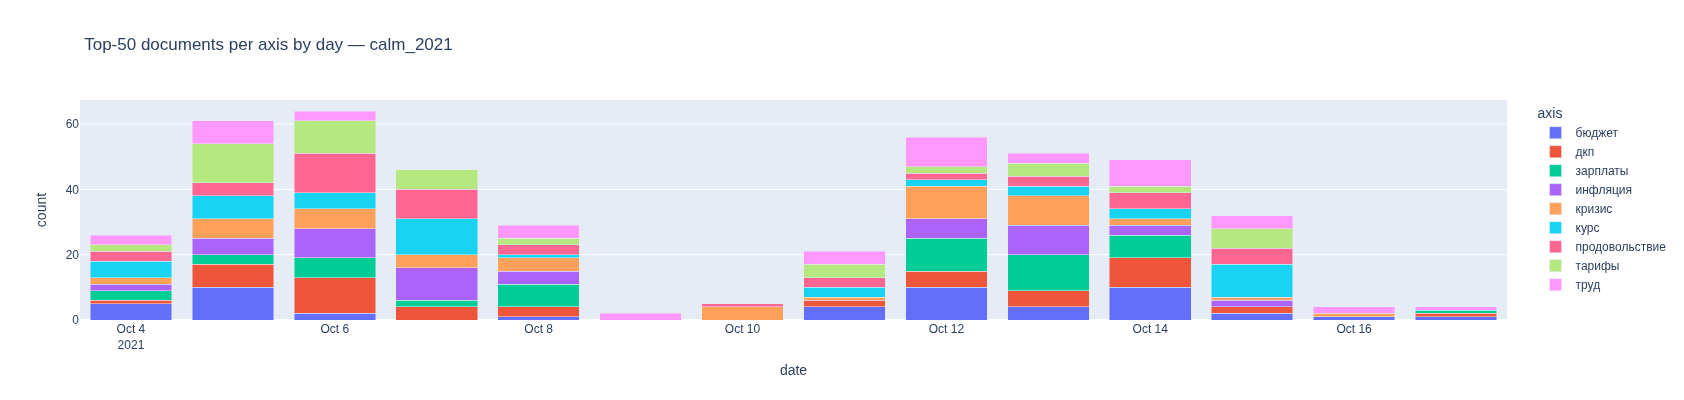

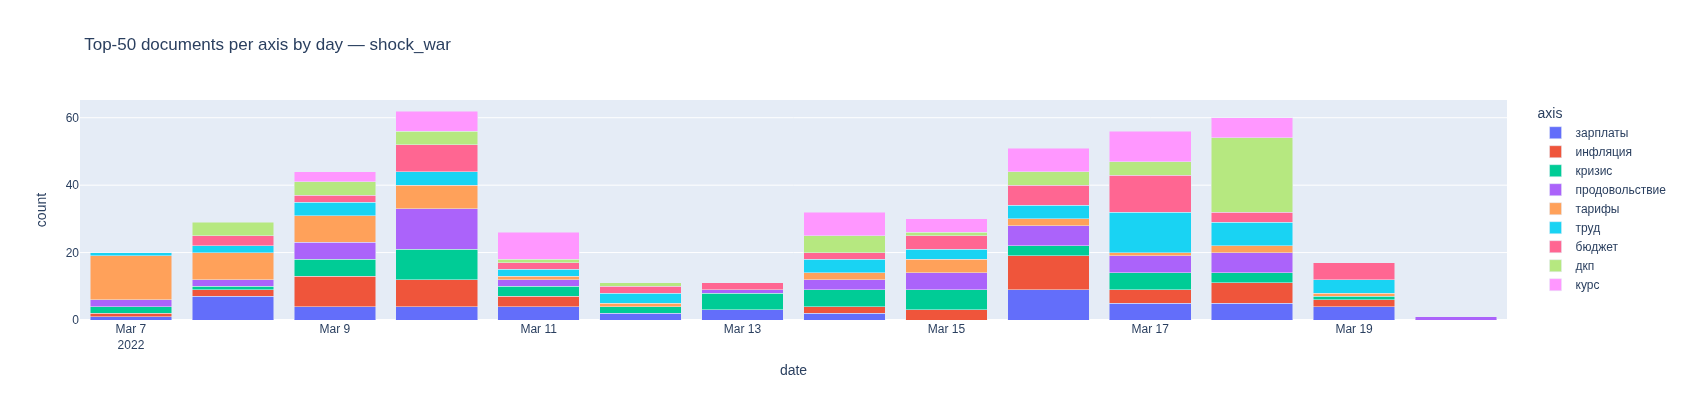

In [38]:
import plotly.express as px

def temporal_topk(topk: dict, period_name: str):
    rows = []
    for axis, df in topk.items():
        for _, row in df.iterrows():
            rows.append({"axis": axis, "date": pd.Timestamp(row["date"]).date()})
    tdf = pd.DataFrame(rows)
    counts = tdf.groupby(["date", "axis"]).size().reset_index(name="count")

    fig = px.bar(
        counts, x="date", y="count", color="axis", barmode="stack",
        title=f"Top-{SANITY_K} documents per axis by day — {period_name}",
        height=400,
    )
    fig.show()


temporal_topk(topk_calm,  "calm_2021")
temporal_topk(topk_shock, "shock_war")

In [39]:
def token_budget(topk: dict, period_name: str):
    union_texts = {}
    for axis_df in topk.values():
        for _, row in axis_df.iterrows():
            union_texts[row["message_id"]] = row["processed_text"]

    lengths = [len(t) for t in union_texts.values()]
    total_chars = sum(lengths)
    total_tokens = int(total_chars * TOKENS_PER_CHAR)

    print(f"\n{period_name}")
    print(f"  unique docs in union: {len(union_texts)}")
    print(f"  avg doc length: {int(total_chars / len(lengths))} chars / ~{int(total_chars / len(lengths) * TOKENS_PER_CHAR)} tokens")
    print(f"  total: {total_chars:,} chars / ~{total_tokens:,} tokens")


token_budget(topk_calm,  "calm_2021")
token_budget(topk_shock, "shock_war")


calm_2021
  unique docs in union: 294
  avg doc length: 191 chars / ~54 tokens
  total: 56,374 chars / ~16,106 tokens

shock_war
  unique docs in union: 355
  avg doc length: 214 chars / ~61 tokens
  total: 76,221 chars / ~21,777 tokens


In [40]:
def show_top(topk: dict, axis: str, period_name: str, n=10):
    df = topk[axis].head(n)
    print(f"\n{'='*60}")
    print(f"Top-{n} | axis={axis} | {period_name}")
    print(f"{'='*60}")
    for _, row in df.iterrows():
        print(f"[{row['channel']}] sim={row['similarity']:.3f} | {str(row['date'])[:10]}")
        print(row["processed_text"][:300])
        print()


for axis in SANITY_AXES:
    show_top(topk_calm,  axis, "calm_2021")
    show_top(topk_shock, axis, "shock_war")


Top-10 | axis=инфляция | calm_2021
[tass_agency] sim=0.594 | 2021-10-13
Годовая инфляция в России в сентябре возросла до 7,4%, большую роль сыграла динамика цен на плодоовощную продукцию, сообщает ЦБ РФ.. Разовые проинфляционные факторы могут дольше держать инфляционные ожидания повышенными, отметили в Банке России.

[rian_ru] sim=0.582 | 2021-10-12
Минэкономразвития повысило прогноз **инфляции в России в 2021 до 7,4% **(с 5,8%). Основной вклад в рост цен вносит продовольственная инфляция, сказал министр.

[rian_ru] sim=0.581 | 2021-10-06
Бургеры в России с начала года в среднем подорожали на 10,4% в годовом выражении (до 311 рублей), картошка фри – на 18% (до 111 рублей), а газированные напитки (0,4 литра) - на 5% (до 72,3 рубля), говорится в исследовании оператора фискальных данных OFD.ru (есть в распоряжении РИА Новости).

[rian_ru] sim=0.580 | 2021-10-13
Рост **цен на бензин** по итогам года планируется на уровне, близком к инфляции, сказал РИА Новости замглавы Минэнерго Сорокин..

# E04: Итоговые решения — входные параметры для E05

## Стратегия RAG-отбора

**Top-K вместо threshold.** Распределение max-similarity унимодальное без естественного провала между сигналом и шумом (медиана calm=0.30, shock=0.33). Абсолютный порог нестабилен между периодами и захватывает шаблонный контент (prime1) эффективнее, чем нарративный. Фиксированный top-K даёт предсказуемый и сопоставимый объём выборки вне зависимости от периода.

**K = 50 на ось.** Union top-K: 294 уникальных документа для calm, 355 для shock (из максимальных 450 слотов). Перекрытие умеренное — оси добавляют уникальный контент, не дублируют друг друга полностью.

## Фильтрация

**Prime1 исключить** перед RAG-поиском (`exclude_channels: [prime1]`). Жанровый выброс — шаблонные маркет-брифы семантически изолированы от новостного нарратива, доминируют в retrieved при любом пороге, не несут полезного сигнала для суммаризации.

## Дедупликация

**Порог: cosine ≥ 0.9.** Выше этого значения — wire-дубли с временны́м окном 0–5 минут (пик time_diff, подтверждён примерами с similarity 0.999). Из группы near-duplicate пар оставлять документ с наибольшей длиной текста.

## Оси запросов

**9 осей сохраняются без изменений.** Зарплаты и труд — кандидаты на объединение (Jaccard 0.25 в shock_war), но в calm_2021 изолированы. Решение отложено до E05 — проверить по содержанию union top-K.

## Стратегия суммаризации

**Flat: union top-K → один LLM-запрос.** Иерархия не нужна:
- Token budget: ~16k токенов (calm), ~22k (shock) — влезает в контекст с запасом
- Temporal distribution: top-K равномерно размазан по периоду, концентрации в 1–2 днях нет
- Flat подход проще и прозрачнее для первого PoC

Усложнение до axis-per-summary → meta-summary только если flat даёт неудовлетворительное качество в E05.

## Параметры зафиксированы в `config/params.yaml` (секция `rag`)

```yaml
scraper:
  batch_size: 200
  inter_batch_sleep: 1.0

proxy:
  host: ""
  port: 1080

preprocessing:
  lead_sentences: 3
  min_text_length: 50
  embed_batch_size: 256

rag:
  # Horizon: days before survey date to collect news
  horizon_days: 14

  # Top-K documents per axis (E04/S03: threshold-based selection doesn't work
  # due to unimodal similarity distribution without a natural signal/noise gap)
  top_k_per_axis: 50

  # Exclude channels with non-narrative content (market briefs)
  exclude_channels:
    - prime1

  # Near-duplicate deduplication threshold (E04/S04: cosine >= 0.9 are wire duplicates,
  # confirmed by time_diff peak at 0-5 min and manual inspection of top pairs)
  dedup_threshold: 0.9

  # RAG query axes (E04/S03: 9 axes retained, зарплаты+труд kept separate)
  axes:
    дкп:
      - "решение по ключевой ставке"
      - "денежно-кредитная политика Банка России"
    инфляция:
      - "рост потребительских цен"
      - "инфляция в России"
    продовольствие:
      - "цены на продукты питания"
    курс:
      - "курс рубля к доллару"
      - "ослабление рубля"
    тарифы:
      - "повышение тарифов ЖКХ"
      - "цены на бензин"
    зарплаты:
      - "рост зарплат"
      - "реальные доходы населения"
    труд:
      - "дефицит кадров в России"
      - "безработица в России"
    кризис:
      - "экономический кризис в России"
      - "экономическая неопределённость"
      - "санкции против России"
    бюджет:
      - "бюджетные расходы"
      - "дефицит бюджета"
```